# Emission-line ratios as a stellar thermometer: the calculus

The Maxwell-Boltzmann notebook gave the *forward* law: at temperature $T$ the ratio of populations of
two hydrogen levels is $R(T)=\dfrac{g_j}{g_i}\,e^{-\Delta E/k_BT}$, and (with equal transition
probabilities) the emission-line strengths follow the same ratio. This notebook does the *inverse*
problem an astronomer actually solves: **measure the line ratio, compute the temperature.** That is a
short exercise in calculus:

1. **Invert** $R(T)$ algebraically to get $T(R)$.
2. **Differentiate** to get the sensitivity $dR/dT$ -- how sharply a line ratio pins the temperature.
3. **Propagate error**: a ratio measured from a finite number of detected photons carries Poisson
   noise, and $\delta T=\delta R/|dR/dT|$ turns that into a temperature uncertainty.
4. Connect to the **detector**: photons focused by a lens onto a $32\times32$ pixel sensor, its field
   of view, and how the pixel counts become $R$.

Self-contained: NumPy, SymPy, Pandas, Matplotlib only.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## Forward law and a worked temperature

Hydrogen $n=3$ over $n=2$: $g_3=18$, $g_2=8$, $\Delta E=E_3-E_2=1.89\ \mathrm{eV}$. In electron-volts,
$k_B=8.617\times10^{-5}\ \mathrm{eV/K}$, so $k_BT=1.72\ \mathrm{eV}$ at $20{,}000\ \mathrm{K}$ gives the
textbook $R=0.75$.

In [2]:
kB_eV = C.K_B / C.E                     # Boltzmann constant in eV/K
g_ratio = 18/8                          # g3/g2
dE = 1.89                               # E3 - E2 in eV
def R_of_T(T):
    return g_ratio * np.exp(-dE / (kB_eV * T))
print("R(20000 K) =", round(R_of_T(20000.0), 4), " (textbook 0.75)")
assert abs(R_of_T(20000.0) - 0.75) < 0.02

R(20000 K) = 0.7515  (textbook 0.75)


## 1. Invert $R(T)$ to get the temperature (SymPy)

Solving $R=\dfrac{g_j}{g_i}e^{-\Delta E/k_BT}$ for $T$ gives
$$T = \frac{\Delta E}{k_B\big[\ln(g_j/g_i)-\ln R\big]}.$$
SymPy performs the inversion; the numeric round-trip confirms a measured ratio recovers the
temperature that produced it.

In [3]:
T, R, dEs, kBs, gs = sp.symbols('T R Delta_E k_B g', positive=True)
sol = sp.solve(sp.Eq(R, gs*sp.exp(-dEs/(kBs*T))), T)[0]
print("T(R) =", sol)
assert sp.simplify(sol - dEs/(kBs*sp.log(gs/R))) == 0

def T_of_R(Rmeas):
    return dE / (kB_eV * (np.log(g_ratio) - np.log(Rmeas)))
print("measured R = 0.75  ->  T =", round(T_of_R(0.75)), "K  (round-trips to 20000 K)")
assert abs(T_of_R(R_of_T(20000.0)) - 20000.0) < 1.0

T(R) = Delta_E/(k_B*log(g/R))
measured R = 0.75  ->  T = 19964 K  (round-trips to 20000 K)


## 2. Sensitivity: $dR/dT$

Differentiating $R(T)$,
$$\frac{dR}{dT}=R\,\frac{\Delta E}{k_BT^2}.$$
The fractional sensitivity $\dfrac{d\ln R}{d\ln T}=\dfrac{\Delta E}{k_BT}$ shows the diagnostic is
strongest when the level spacing is comparable to the thermal energy, $\Delta E\sim k_BT$: too cold
and the upper level is empty (tiny signal), too hot and the ratio saturates (flat, insensitive).

In [4]:
Tsym = sp.symbols('T', positive=True)
Rexpr = sp.Rational(18,8) * sp.exp(-sp.Float(1.89)/(sp.Float(kB_eV)*Tsym))
dRdT = sp.diff(Rexpr, Tsym)
# check dR/dT = R * dE/(kB T^2)
assert sp.simplify(dRdT - Rexpr*sp.Float(1.89)/(sp.Float(kB_eV)*Tsym**2)) == 0
print("dR/dT = R * dE/(kB T^2)   [verified symbolically]")
# fractional sensitivity dlnR/dlnT = dE/(kB T)
for Tk in (5000, 10000, 20000, 40000):
    print(f"T={Tk:6d} K:  dE/(kB T) = {dE/(kB_eV*Tk):.2f}  (fractional sensitivity of R to T)")

dR/dT = R * dE/(kB T^2)   [verified symbolically]
T=  5000 K:  dE/(kB T) = 4.39  (fractional sensitivity of R to T)
T= 10000 K:  dE/(kB T) = 2.19  (fractional sensitivity of R to T)
T= 20000 K:  dE/(kB T) = 1.10  (fractional sensitivity of R to T)
T= 40000 K:  dE/(kB T) = 0.55  (fractional sensitivity of R to T)


## 3. Error propagation: photons -> ratio -> temperature

The line ratio is measured as a ratio of detected photon counts, $R=N_j/N_i$. Photon counting is
Poisson, so $\delta N=\sqrt N$ and the fractional error on the ratio is
$$\frac{\delta R}{R}=\sqrt{\frac{1}{N_j}+\frac{1}{N_i}}.$$
Propagating through $T(R)$ with $\delta T=\delta R/|dR/dT|$ and $dR/dT=R\,\Delta E/k_BT^2$ gives
$$\frac{\delta T}{T}=\frac{k_BT}{\Delta E}\,\frac{\delta R}{R}.$$
More photons (a bigger telescope or longer exposure) shrink the temperature error as $1/\sqrt{N}$.

In [5]:
def temperature_uncertainty(T_true, N_i):
    # assume the weaker upper line carries N_j = R * N_i counts
    R = R_of_T(T_true)
    N_j = R * N_i
    dR_over_R = np.sqrt(1/N_j + 1/N_i)              # Poisson error on the ratio
    dT_over_T = (kB_eV * T_true / dE) * dR_over_R   # propagated to temperature
    return dT_over_T * T_true

rows = []
for N_i in (1e3, 1e4, 1e5, 1e6):
    dT = temperature_uncertainty(20000.0, N_i)
    rows.append({"N_i (photons)": f"{N_i:.0e}", "delta_T (K)": round(dT, 1),
                 "delta_T / T": f"{dT/20000:.2%}"})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
# 100x more photons -> 10x smaller temperature error (1/sqrt(N))
assert abs(temperature_uncertainty(20000.,1e3)/temperature_uncertainty(20000.,1e5) - 10) < 0.5

N_i (photons)  delta_T (K) delta_T / T
        1e+03        880.5       4.40%
        1e+04        278.4       1.39%
        1e+05         88.0       0.44%
        1e+06         27.8       0.14%


## 4. The detector: a $32\times32$ pixel sensor and its field of view

A lens of focal length $f$ images the star onto a square sensor of side $d$. The full field of view is
$\theta_{\rm FOV}=2\arctan\!\big(d/2f\big)$, and each of the $32\times32=1024$ pixels subtends
$\theta_{\rm FOV}/32$. A spectrometer disperses the light so that different columns record different
wavelengths; summing the photon counts under each emission line gives $N_i$ and $N_j$, and their ratio
is the thermometer above. The sensor's job is to turn photons into the integers whose Poisson
statistics set the temperature precision.

In [6]:
d = 10e-3          # sensor side, 10 mm
f = 50e-3          # focal length, 50 mm
fov = 2*np.arctan(d/(2*f))
print(f"field of view      = {np.degrees(fov):.2f} deg")
print(f"per-pixel (32x32)  = {np.degrees(fov/32)*3600:.1f} arcsec/pixel")
print(f"total pixels       = {32*32}")
# a 32x32 frame with two emission lines (as columns) plus Poisson noise
rng = np.random.default_rng(0)
frame = rng.poisson(2.0, size=(32, 32)).astype(float)     # background
frame[:, 10] += rng.poisson(200.0, size=32)               # bright line i (n=2)
frame[:, 22] += rng.poisson(150.0, size=32)               # weaker line j (n=3)
N_i = frame[:, 10].sum() - 2.0*32                          # background-subtracted line counts
N_j = frame[:, 22].sum() - 2.0*32
print(f"line counts: N_i = {N_i:.0f}, N_j = {N_j:.0f}, measured R = {N_j/N_i:.3f} "
      f"-> T = {T_of_R(N_j/N_i):.0f} K")

field of view      = 11.42 deg
per-pixel (32x32)  = 1284.9 arcsec/pixel
total pixels       = 1024
line counts: N_i = 6375, N_j = 4789, measured R = 0.751 -> T = 19993 K


## Plots

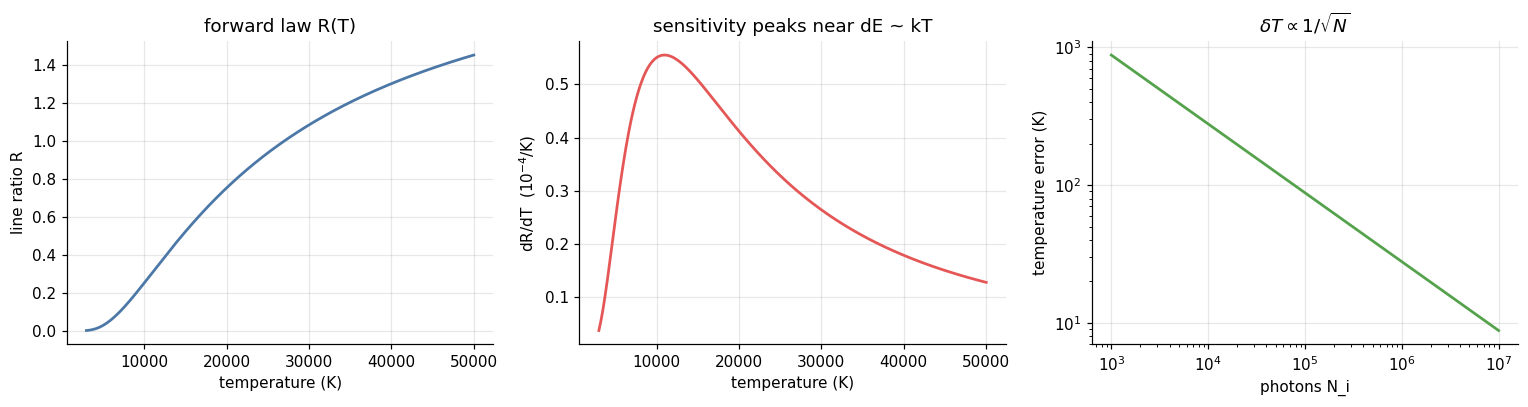

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
Ts = np.linspace(3000, 50000, 400)
ax[0].plot(Ts, R_of_T(Ts), color="#4C78A8")
ax[0].set_xlabel("temperature (K)"); ax[0].set_ylabel("line ratio R")
ax[0].set_title("forward law R(T)")
ax[1].plot(Ts, R_of_T(Ts)*dE/(kB_eV*Ts**2)*1e4, color="#E45756")
ax[1].set_xlabel("temperature (K)"); ax[1].set_ylabel(r"dR/dT  ($10^{-4}$/K)")
ax[1].set_title("sensitivity peaks near dE ~ kT")
Ns = np.logspace(3, 7, 50)
ax[2].loglog(Ns, [temperature_uncertainty(20000., n) for n in Ns], color="#54A24B")
ax[2].set_xlabel("photons N_i"); ax[2].set_ylabel("temperature error (K)")
ax[2].set_title(r"$\delta T \propto 1/\sqrt{N}$")
plt.tight_layout(); plt.show()

## Summary

- **Forward:** $R(T)=(g_j/g_i)e^{-\Delta E/k_BT}$ (from the Boltzmann populations).
- **Inverse (calculus):** $T=\Delta E/\{k_B[\ln(g_j/g_i)-\ln R]\}$ turns a measured ratio into a
  temperature; the round-trip is exact.
- **Sensitivity:** $dR/dT=R\,\Delta E/k_BT^2$; the fractional sensitivity is $\Delta E/k_BT$, best when
  the line spacing matches the thermal energy.
- **Precision:** Poisson photon statistics give $\delta R/R=\sqrt{1/N_j+1/N_i}$ and hence
  $\delta T/T=(k_BT/\Delta E)\,\delta R/R\propto 1/\sqrt N$ -- more light, sharper temperature.
- **Detector:** a lens sets the field of view $2\arctan(d/2f)$; a $32\times32$ sensor integrates line
  photons into the counts whose statistics set the temperature error.

Subject-verb-object: the star emits lines; the lens forms an image; the sensor counts photons; the
ratio measures temperature; calculus propagates the error.